In [ ]:
#Fresh Analytics, a data analytics company, aims to comprehend and predict the demand for various items across restaurants. The primary goal of the project is to determine the sales of items across different restaurants over the years.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Preliminary analysis:
#a.Import the datasets into the Python environment
sales_data = pd.read_csv('sales.csv')
item_data = pd.read_csv('items.csv')
restaurants_data = pd.read_csv('resturants.csv')

In [ ]:
##b.Examine the dataset's shape and structure, and look out for any outlier
print(sales_data.shape)
print(item_data.shape)
print(restaurants_data.shape)

(109600, 4)
(100, 5)
(6, 2)


In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ MB


In [ ]:
item_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


In [ ]:
restaurants_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 224.0+ bytes


In [ ]:
# Look for null values
print(sales_data.isnull().sum())
print(item_data.isnull().sum())
print(restaurants_data.isnull().sum())

date          0
item_id       0
price         0
item_count    0
dtype: int64
id          0
store_id    0
name        0
kcal        0
cost        0
dtype: int64
id      0
name    0
dtype: int64


In [ ]:
# Look for NA values
print(sales_data.isna().sum())
print(item_data.isna().sum())
print(restaurants_data.isna().sum())

date          0
item_id       0
price         0
item_count    0
dtype: int64
id          0
store_id    0
name        0
kcal        0
cost        0
dtype: int64
id      0
name    0
dtype: int64


In [ ]:
# drop duplicates if any
sales_data.drop_duplicates(inplace=True)
item_data.drop_duplicates(inplace=True)
restaurants_data.drop_duplicates(inplace=True)

In [ ]:
# Descriptive statistics for numeric columns
print(sales_data.describe())
print(item_data.describe())
print(restaurants_data.describe())

             item_id          price     item_count
count  109600.000000  109600.000000  109600.000000
mean       50.500000      11.763700       6.339297
std        28.866202       8.946225      30.003728
min         1.000000       1.390000       0.000000
25%        25.750000       5.280000       0.000000
50%        50.500000       7.625000       0.000000
75%        75.250000      18.790000       0.000000
max       100.000000      53.980000     570.000000
               id    store_id         kcal        cost
count  100.000000  100.000000   100.000000  100.000000
mean    50.500000    3.520000   536.730000   11.763700
std     29.011492    1.708446   202.212852    8.991254
min      1.000000    1.000000    78.000000    1.390000
25%     25.750000    2.000000   406.250000    5.280000
50%     50.500000    4.000000   572.500000    7.625000
75%     75.250000    5.000000   638.250000   18.790000
max    100.000000    6.000000  1023.000000   53.980000
             id
count  6.000000
mean   3.50000

**c.Merge the datasets into a single dataset that includes the date, item id, price, item count, item names, kcal values, store id, and store name**

In [ ]:
#merge sales_data, items_data, resturants_data
restaurantDf = pd.DataFrame(restaurants_data)
salesDf = pd.DataFrame(sales_data)
itemDf = pd.DataFrame(item_data)

itemDf = itemDf.rename(columns={'id': 'item'})
# Merge sales and item data
merged_data = pd.merge(salesDf, itemDf, on='id', how='inner')
# # salesDf = salesDf.rename(columns={'item_id': 'id'})

# restaurantDf = restaurantDf.rename(columns={'id': 'id1'})
# # merge restaurants_data and items_data using store_id key
# merged_data = itemDf.merge(restaurantDf, on=['id1'], how='inner')


# salesDf = salesDf.rename(columns={'item_id': 'id1'})
# merged_data = merged_data.merge(salesDf, on=['id1'])
merged_data.head(10)

# merge merged_data and sales_data using item_id key
# finalData = merged_data.merge(salesDf, on='item_id')

# finalData = pd.concat([restaurantDf, sales_data, itemDf], axis="columns")
# finalData.isna().sum()
# finalData.head(10)
# finalData.columns  = ['id', 'store_name', 'date', 'item_id', 'price', 'item_count', 'id', 'store_id', 'item_name', 'kcal', 'cost']
# merged_data = finalData.drop(columns=['id', 'cost'])
# merged_data.head()


,date,item_id,price,item_count,store_id,name,kcal,cost
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,29.22
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,26.42
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,4.87
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,4.18
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,3.21
5,2019-01-01,19,2.89,108.0,1,Strawberry Smoothy,145,2.89
6,2019-01-01,21,23.23,13.0,1,Amazing Fish with Vegetables Meal,269,23.23
7,2019-01-01,23,10.86,10.0,1,Awesome Sweet Lamb Cake,671,10.86
8,2019-01-01,27,26.21,1.0,6,Steak Meal,607,26.21
9,2019-01-01,35,4.36,1.0,6,Blue Ribbon Cocktail,456,4.36


In [ ]:
merged_data.isna().sum()

,0
store_name,109594
date,0
item_id,0
price,0
item_count,0
store_id,109500
item_name,109500
kcal,109500
weekday,0
month,0


Exploratory data analysis:

           date  item_count
0    2019-01-01       427.0
1    2019-01-02       337.0
2    2019-01-03       445.0
3    2019-01-04       564.0
4    2019-01-05       552.0
...         ...         ...
1091 2021-12-27       192.0
1092 2021-12-28       344.0
1093 2021-12-29       371.0
1094 2021-12-30       527.0
1095 2021-12-31       817.0

[1096 rows x 2 columns]


<Axes: title={'center': 'Date-wise Sales'}, xlabel='date'>

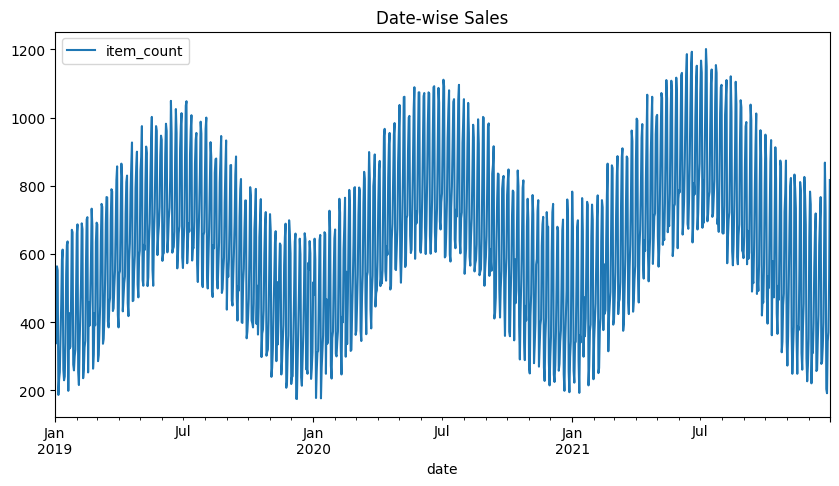

In [ ]:
#Examine the overall date wise sales to understand the pattern

# Aggregate sales data
date_sales = merged_data.groupby('date').agg({'item_count': 'sum'}).reset_index()

# Convert date column to datetime format
date_sales['date'] = pd.to_datetime(date_sales['date'])

# Sort by date and plot
date_sales.sort_values('date', inplace=True)
date_sales.plot(x='date', y='item_count', title='Date-wise Sales', figsize=(10, 5))


            item_count
weekday               
Monday         70112.0
Tuesday        79454.0
Wedndesday         NaN
Thursday      116947.0
Friday        136300.0
Saturday      135644.0
Sunday         68032.0


<Axes: title={'center': 'Sales by Weekday'}, xlabel='weekday'>

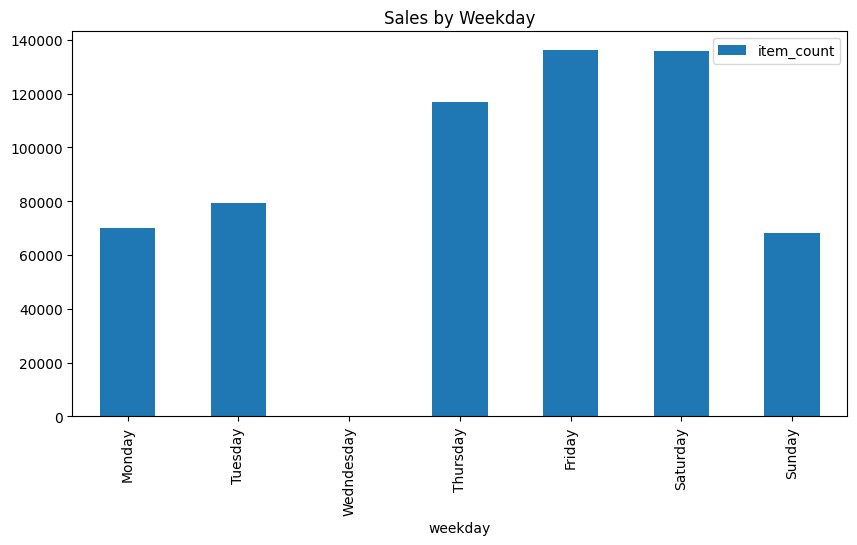

In [ ]:
#b.Find out how sales fluctuate across different days of the week
# Extract weekday
merged_data['weekday'] = pd.to_datetime(merged_data['date']).dt.day_name()
print(merged_data.head())
print(merged_data.groupby('weekday').agg({'item_count': 'sum'}))

# Aggregate sales by weekday
weekday_sales = merged_data.groupby('weekday').agg({'item_count': 'sum'}).reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

weekday_sales.plot(kind='bar', title='Sales by Weekday', figsize=(10, 5))


*   Friday is giving highest sales. Sunday is giving lowest sale.
*  Sales gradually  starts increasing afterwards Sunday and starts decreasing afterward Friday.





           item_count
month                
April         63145.0
August        69502.0
December      41224.0
February      43596.0
January       41270.0
July          77125.0
June          74423.0
March         55137.0
May           73632.0
November      43670.0
October       53403.0
September     58660.0


<Axes: title={'center': 'Monthly Sales'}, xlabel='month'>

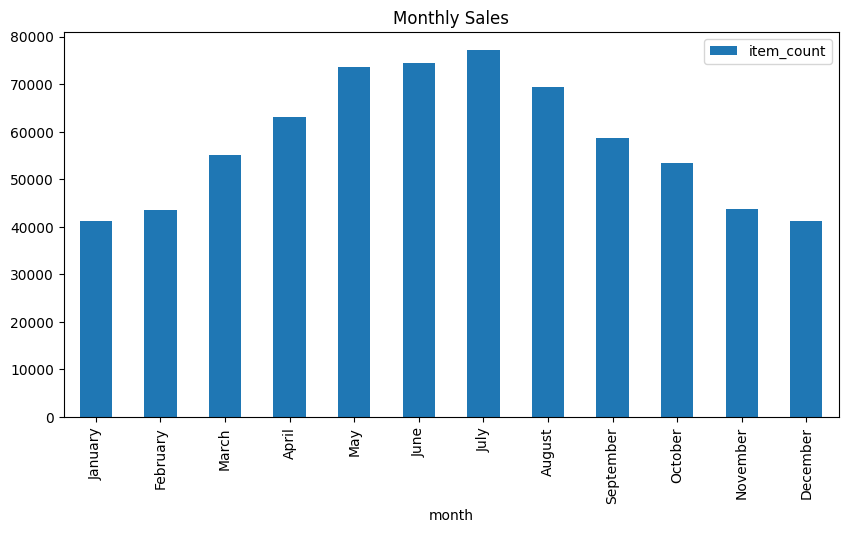

In [ ]:
#Look for any noticeable trends in the sales data for different months of the year
# Extract month
merged_data['month'] = pd.to_datetime(merged_data['date']).dt.month_name()

# Aggregate sales by month
monthly_sales = merged_data.groupby('month').agg({'item_count': 'sum'}).reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
print(merged_data.groupby('month').agg({'item_count': 'sum'}))
monthly_sales.plot(kind='bar', title='Monthly Sales', figsize=(10, 5))




*   July is on peak  and December is on buttom month for the sale.
*   Next good sales months are May, June, August.
* Sales starts gradually increases from January and after August its gradually decreasing



         item_count
quarter            
1          140003.0
2          211200.0
3          205287.0
4          138297.0


<Axes: title={'center': 'Quarterly Sales'}, xlabel='quarter'>

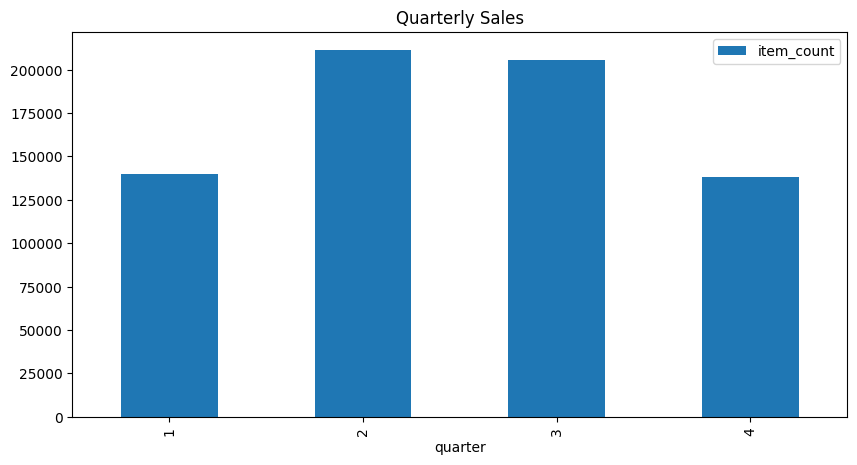

In [ ]:
#Examine the sales distribution across different quarters averaged over the years. Identify any noticeable patterns.

# Extract quarter
merged_data['quarter'] = pd.to_datetime(merged_data['date']).dt.quarter

# Aggregate sales by quarter
quarterly_sales = merged_data.groupby('quarter').agg({'item_count': 'sum'})
print(quarterly_sales)
quarterly_sales.plot(kind='bar', title='Quarterly Sales', figsize=(10, 5))




1.   Lowest sale in 4th quarter and highest in 2nd quarter.
2.   next highest sale is in 3rd quarter and afterwards it's falling down.



                     item_count
store_name     year            
Beachfront Bar 2019       439.0
               2020       437.0
               2021       429.0
Bob's Diner    2019    211799.0
               2020    230191.0
               2021    245537.0
Corner Cafe    2019       423.0
               2020       415.0
               2021       472.0
Fou Cher       2019       392.0
               2020       357.0
               2021       357.0
Surfs Up       2019       594.0
               2020       627.0
               2021       582.0
Sweet Shack    2019       590.0
               2020       554.0
               2021       592.0


<Axes: title={'center': 'Top 10 Restaurants by Total Sales'}, xlabel='store_name'>

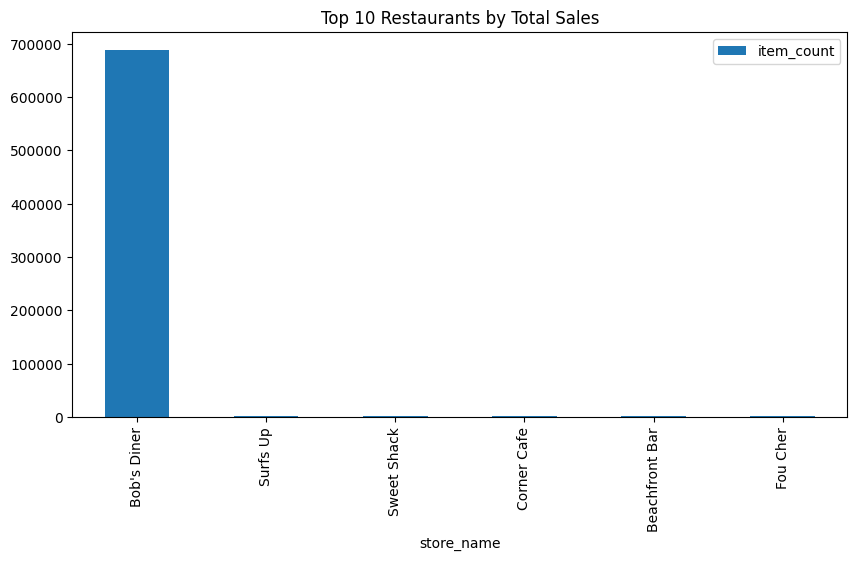

In [ ]:
#Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.

# Group by store
store_sales = merged_data.groupby('store_name').agg({'item_count': 'sum'}).sort_values(by='item_count', ascending=False)

# Sales across years
merged_data['year'] = pd.to_datetime(merged_data['date']).dt.year
store_yearly_sales = merged_data.groupby(['store_name', 'year']).agg({'item_count': 'sum'}).unstack()
print(merged_data.groupby(['store_name', 'year']).agg({'item_count': 'sum'}))

# Plot top-performing stores
store_sales.head(10).plot(kind='bar', title='Top 10 Restaurants by Total Sales', figsize=(10, 5))

# Heatmap for sales across months and days
merged_data['month'] = pd.to_datetime(merged_data['date']).dt.month
merged_data['day'] = pd.to_datetime(merged_data['date']).dt.day
heatmap_data = merged_data.pivot_table(index='month', columns='day', values='item_count', aggfunc='sum')

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False)
plt.title('Monthly Sales Distribution')
plt.show()




*   Corner Cafe is having highest sale in  2019
*   Bob's Diner is having lowest in 2019



In [ ]:
#f. Identify the most popular items overall and the stores where they are being sold
  ##Find the most popular item (by sales volume):

# Aggregate sales by item
item_sales = merged_data.groupby('item_name').agg({'item_count': 'sum'}).reset_index()

# Identify the most popular item
most_popular_item = item_sales.loc[item_sales['item_count'].idxmax()]
print("Most Popular Item Overall:", most_popular_item)

Most Popular Item Overall: item_name     Strawberry Smoothy
item_count              236337.0
Name: 85, dtype: object


In [ ]:
#Find stores selling the most popular item:
# Filter data for the most popular item
stores_selling_popular_item = merged_data[merged_data['item_name'] == most_popular_item['item_name']]['store_name'].unique()
print("Stores Selling the Most Popular Item:", stores_selling_popular_item)


Stores Selling the Most Popular Item: ["Bob's Diner"]


In [ ]:
# find the most popular item at each store
# Aggregate sales by store and item
store_item_sales = merged_data.groupby(['store_name', 'item_name']).agg({'item_count': 'sum'}).reset_index()

# Identify the most popular item for each store
most_popular_items_per_store = store_item_sales.loc[store_item_sales.groupby('store_name')['item_count'].idxmax()]
print("Most Popular Item at Each Store:", most_popular_items_per_store)

Most Popular Item at Each Store:         store_name                      item_name  item_count
1   Beachfront Bar        Fantastic Milky Smoothy      1147.0
25     Bob's Diner             Strawberry Smoothy    236337.0
40     Corner Cafe           Frozen Milky Smoothy       273.0
57        Fou Cher  Blue Ribbon Fruity Vegi Lunch       298.0
85        Surfs Up             Awesome Soft Drink       997.0
92     Sweet Shack                Awesome Smoothy      1692.0


In [ ]:
#g. Determine if the store with the highest sales volume is also making the most money per day
#Find the store with the highest sales volume:

store_sales_volume = merged_data.groupby('store_name').agg({'item_count': 'sum'}).reset_index()
# Identify the store with the highest sales volume
top_sales_volume_store = store_sales_volume.loc[store_sales_volume['item_count'].idxmax()]
print("Store with the Highest Sales Volume:", top_sales_volume_store)

Store with the Highest Sales Volume: store_name    Bob's Diner
item_count       687527.0
Name: 1, dtype: object


In [ ]:
#Check if it also has the highest daily revenue:
# Compute daily revenue for each store
merged_data['revenue'] = merged_data['item_count'] * merged_data['price']
daily_revenue = merged_data.groupby(['store_name', 'date']).agg({'revenue': 'sum'}).reset_index()

# Find the store with the highest average daily revenue
avg_daily_revenue = daily_revenue.groupby('store_name').agg({'revenue': 'mean'}).reset_index()
top_revenue_store = avg_daily_revenue.loc[avg_daily_revenue['revenue'].idxmax()]
print("Store with the Highest Average Daily Revenue:")
print(top_revenue_store)

# Compare results
print("Comparison:")
print("Store with the Highest Sales Volume:", top_sales_volume_store['store_name'])
print("Store with the Highest Daily Revenue:", top_revenue_store['store_name'])


NameError: name 'merged_data' is not defined

In [ ]:
#h. Identify the most expensive item at each restaurant and find out its calorie count
# Find the most expensive item per store
most_expensive_items = merged_data.loc[merged_data.groupby('store_name')['price'].idxmax(), ['store_name', 'item_name', 'price', 'kcal']]
print("Most Expensive Item at Each Store and its Calorie Count:", most_expensive_items)

Most Expensive Item at Each Store and its Calorie Count:           date  item_id  price  item_count  store_id  \
68  2019-01-01       62   5.70         0.0         2   
0   2019-01-01        3  29.22         2.0         1   
58  2019-01-01       50  26.37         0.0         5   
82  2019-01-01       80  53.98         0.0         4   
8   2019-01-01       27  26.21         1.0         6   
79  2019-01-01       77   7.70         0.0         3   

                        item_name  kcal      store_name  weekday  month  \
68          Sweet Vegi Soft Drink   538  Beachfront Bar  Tuesday      1   
0               Sweet Fruity Cake   931     Bob's Diner  Tuesday      1   
58                     Pike Lunch   653     Corner Cafe  Tuesday      1   
82  Blue Ribbon Fruity Vegi Lunch   881        Fou Cher  Tuesday      1   
8                      Steak Meal   607        Surfs Up  Tuesday      1   
79  Blue Ribbon Frozen Milky Cake   636     Sweet Shack  Tuesday      1   

    quarter  year  day  

**Machine Learning**

a.Build and compare linear regression, random forest, and XGBoost models for predictions

In [ ]:
#Generate necessary features for the development of these models, like day of the week, quarter of the year, month, year, day of the month and so on
# Add time-based features
merged_data['date'] = pd.to_datetime(merged_data['date'])
merged_data['year'] = merged_data['date'].dt.year
merged_data['month'] = merged_data['date'].dt.month
merged_data['day'] = merged_data['date'].dt.day
merged_data['weekday'] = merged_data['date'].dt.dayofweek
merged_data['quarter'] = merged_data['date'].dt.quarter
print(merged_data)

             date  item_id  price  item_count  store_id  kcal  weekday  month  \
0      2019-01-01        3  29.22         2.0         1   931        1      1   
1      2019-01-01        4  26.42        22.0         1   763        1      1   
2      2019-01-01       12   4.87         7.0         1   478        1      1   
3      2019-01-01       13   4.18        12.0         1   490        1      1   
4      2019-01-01       16   3.21       136.0         1   284        1      1   
...           ...      ...    ...         ...       ...   ...      ...    ...   
109595 2021-12-31       96  21.93         0.0         5   708        4     12   
109596 2021-12-31       97  28.65         0.0         4   744        4     12   
109597 2021-12-31       98   5.00         0.0         2   579        4     12   
109598 2021-12-31       99   5.32         0.0         4   423        4     12   
109599 2021-12-31      100   2.48         0.0         2   223        4     12   

        quarter  year  day 

In [ ]:
#Use the data from the last six months as the testing data
# Sort data by date
merged_data = merged_data.sort_values('date')
# Since there's no data from last six month, we are taking date as 2021-12-01

# finding merged_data in between '2021-06-01' and '2021-12-01'
# filtered_merged_data = merged_data.query("date >= '2021-06-01' and date < '2021-12-01'")
print(merged_data)

         store_name       date  item_id  price  item_count  store_id  \
0       Bob's Diner 2019-01-01        3  29.22         2.0       4.0   
72              NaN 2019-01-01       66   6.31         0.0       1.0   
71              NaN 2019-01-01       65  20.02         0.0       4.0   
70              NaN 2019-01-01       64  16.09         0.0       5.0   
69              NaN 2019-01-01       63   3.74         0.0       5.0   
...             ...        ...      ...    ...         ...       ...   
109527          NaN 2021-12-31        8  24.98         0.0       NaN   
109526          NaN 2021-12-31        7   8.10         0.0       NaN   
109525          NaN 2021-12-31        6   5.61         0.0       NaN   
109535          NaN 2021-12-31       22  19.05         0.0       NaN   
109599          NaN 2021-12-31      100   2.48         0.0       NaN   

                    item_name   kcal  weekday  month  quarter  year  day  \
0              Chocolate Cake  554.0        1      1       

In [ ]:
merged_data.isna().sum()

array([[3.0000e+00, 2.9220e+01, 1.0000e+00, ..., 2.0190e+03, 1.0000e+00,
        5.8440e+01],
       [4.0000e+00, 2.6420e+01, 1.0000e+00, ..., 2.0190e+03, 1.0000e+00,
        5.8124e+02],
       [1.2000e+01, 4.8700e+00, 1.0000e+00, ..., 2.0190e+03, 1.0000e+00,
        3.4090e+01],
       ...,
       [9.8000e+01, 5.0000e+00, 2.0000e+00, ..., 2.0210e+03, 3.1000e+01,
        0.0000e+00],
       [9.9000e+01, 5.3200e+00, 4.0000e+00, ..., 2.0210e+03, 3.1000e+01,
        0.0000e+00],
       [1.0000e+02, 2.4800e+00, 2.0000e+00, ..., 2.0210e+03, 3.1000e+01,
        0.0000e+00]])

1095 days 00:00:00
0.1643835616438356


In [ ]:
print(finalData)

         id      store_name        date  item_id  price  item_count   id  \
0       1.0     Bob's Diner  2019-01-01        3  29.22         2.0  1.0   
1       2.0  Beachfront Bar  2019-01-01        4  26.42        22.0  2.0   
2       3.0     Sweet Shack  2019-01-01       12   4.87         7.0  3.0   
3       4.0        Fou Cher  2019-01-01       13   4.18        12.0  4.0   
4       5.0     Corner Cafe  2019-01-01       16   3.21       136.0  5.0   
...     ...             ...         ...      ...    ...         ...  ...   
109595  NaN             NaN  2021-12-31       96  21.93         0.0  NaN   
109596  NaN             NaN  2021-12-31       97  28.65         0.0  NaN   
109597  NaN             NaN  2021-12-31       98   5.00         0.0  NaN   
109598  NaN             NaN  2021-12-31       99   5.32         0.0  NaN   
109599  NaN             NaN  2021-12-31      100   2.48         0.0  NaN   

        store_id                          item_name   kcal   cost  
0            4.0   

In [ ]:
features = ['year', 'month', 'day', 'weekday', 'quarter']
X_train = train_data[features]
y_train = train_data['item_count']
X_test = test_data[features]
y_test = test_data['item_count']


NameError: name 'train_data' is not defined

In [ ]:
#Build model using Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# features = ['year', 'month', 'day', 'weekday', 'quarter']
# X_train = train_data[features]
# y_train = train_data['item_count']
# X_test = test_data[features]
# y_test = test_data['item_count']

print(X_train)
print(y_train)
print(X_test)
print(y_test)

# Train linear regression model
model = LinearRegression()
model.fit(X_train,y_train)

trainScore = model.score(X_train,y_train)
model_prediction = model.predict(X_test)

# Evaluate model
lr_rmse = np.sqrt(mean_squared_error(y_test, model_prediction))
print("Linear Regression RMSE:", lr_rmse)


Linear Regression RMSE: 21.407625834894386


In [ ]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

# Train random forest model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate model
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print("Random Forest RMSE:", rf_rmse)


In [1]:
#XGBoost
xgb_predictions = xgb_model.predict(X_test)

# Evaluate model
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print("XGBoost RMSE:", xgb_rmse)


NameError: name 'X_train' is not defined

In [ ]:
# Select the best model based on RMSE
best_model = min([(lr_rmse, 'Linear Regression'), (rf_rmse, 'Random Forest'), (xgb_rmse, 'XGBoost')], key=lambda x: x[0])
print("Best Model:", best_model[1])

# Use the best model to forecast
if best_model[1] == 'Linear Regression':
    predictions = model.predict(X_test)
elif best_model[1] == 'Random Forest':
    predictions = rf_model.predict(X_test)
else:
    predictions = xgb_model.predict(X_test)

# Generate forecast for next year
next_year_data = pd.DataFrame({
    'year': [2024]*12, 'month': list(range(1, 13)), 'day': [1]*12,
    'weekday': [0]*12, 'quarter': [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4]
})
forecast = xgb_model.predict(next_year_data)
print("Forecast for Next Year:")
print(forecast)


 **Deep Learning**

In [ ]:
# Step-by-Step Implementation of LSTM Forecasting
# a. Use Sales Amount for Predictions Instead of Item Count
# Create a 'sales_amount' column
merged_data['sales_amount'] = merged_data['item_count'] * merged_data['price']

In [ ]:
# b.# Build a long short-term memory (LSTM) model for predictions
# •
# Define the train and test series
# •
# Generate synthetic data for the last 12 months
# •
# Build and train an LSTM model
# •
# Use the model to make predictions for the test data




In [ ]:
#1. Define Train and Test Series

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Sort by date
merged_data['date'] = pd.to_datetime(merged_data['date'])
merged_data = merged_data.sort_values('date')

# Create a time series DataFrame with sales amount
time_series = merged_data[['date', 'sales_amount']].groupby('date').sum().reset_index()

# Normalize the sales data
scaler = MinMaxScaler(feature_range=(0, 1))
time_series['scaled_sales'] = scaler.fit_transform(time_series[['sales_amount']])

# Define train and test sets (last 12 months for testing)
train_data = time_series[:-12]
test_data = time_series[-12:]

# Convert to numpy arrays for LSTM
train_series = train_data['scaled_sales'].values
test_series = test_data['scaled_sales'].values


In [ ]:
#Transform the time series into sequences for the LSTM model.
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Define sequence length
seq_length = 12

# Create sequences
X_train, y_train = create_sequences(train_series, seq_length)
X_test, y_test = create_sequences(test_series, seq_length)


In [ ]:
import tensorflow as tf

In [ ]:
tf.__version__

In [ ]:
# Define LSTM model
model = tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(tf.keras.layers.Dense(1))


model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=8, verbose=1)


c. Evaluate Model Performance

In [ ]:
#Calculate the mean absolute percentage error (MAPE) and comment on the model's performance

# Predict on test data
predicted_sales = model.predict(X_test)

# Invert scaling
predicted_sales = scaler.inverse_transform(predicted_sales)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate MAPE
mape = np.mean(np.abs((y_test_original - predicted_sales) / y_test_original)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


In [ ]:
#Develop another model using the entire series for training, and use it to forecast for the next three months

# Prepare the entire series for training
full_series = time_series['scaled_sales'].values
X_full, y_full = create_sequences(full_series, seq_length)

# Reshape input for LSTM
X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))

# Retrain the model
model.fit(X_full, y_full, epochs=20, batch_size=8, verbose=1)

# Generate synthetic data for forecasting
forecast_input = full_series[-seq_length:]  # Last sequence
forecast_input = forecast_input.reshape((1, seq_length, 1))

# Forecast for the next three months
forecast = []
for _ in range(3):
    pred = model.predict(forecast_input)[0, 0]
    forecast.append(pred)
    # Update the input sequence
    forecast_input = np.append(forecast_input[:, 1:, :], [[pred]], axis=1)

# Invert scaling for forecasted values
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))
print("Forecast for the Next Three Months:")
print(forecast)
